# **CA3 - Reinforcement Learning**

In [3]:
import sys
!{sys.executable} -m pip install -i https://mirror-pypi.runflare.com/simple "gym==0.26.2" "numpy<2" pygame matplotlib --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://mirror-pypi.runflare.com/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 2.9 MB/s eta 0:00:00 MB/s eta 0:00:01:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827729 sha256=8753a4371c2e70e3b9e16f07d9d8486c56681bfb95662d437794c7c6f3196f83
  Stored in directory: /home/armin/.cache/pip/wheels/63/b3/6b/c2f6e551a6e8c85c9fef19ea8b97ad7b7c5eba21c929848bdc
Successfully built gym


In [5]:
import gym
import math
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### **PART 1: AGENT IMPLEMENTATION**

In [7]:
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

/tmp/ipykernel_5920/920200510.py:1: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not hasattr(np, "bool8"):


In [16]:
import numpy as np
from collections import deque
import math

class QLearningAgent:
    def __init__(
        self,
        env,
        buckets=(40, 40),
        alpha=0.05,
        gamma=0.99,
        epsilon_strategy='exponential',
        episodes=100000,
        seed=400
    ):
        self.env = env
        self.buckets = buckets
        self.alpha = alpha
        self.gamma = gamma
        self.episodes = episodes
        self.epsilon_strategy = epsilon_strategy
        self.seed = seed

        self.rng = np.random.default_rng(seed)
        self.env.action_space.seed(seed)

        self.lower_bounds = self.env.observation_space.low
        self.upper_bounds = self.env.observation_space.high

        self.Q_table = np.zeros(self.buckets + (self.env.action_space.n,))

        self.threshold = self.env.spec.reward_threshold
        print('threshold:', self.threshold)

    def reset_env(self, episode=0):
        reset_result = self.env.reset(seed=self.seed + episode)

        if isinstance(reset_result, tuple):
            obs = reset_result[0]
        else:
            obs = reset_result

        return obs

    def discretize_state(self, obs):
        
        ratios = (obs - self.lower_bounds) / (self.upper_bounds - self.lower_bounds)
        new_obs = np.round(ratios * (np.array(self.buckets) - 1)).astype(int)
        new_obs = np.clip(new_obs, 0, np.array(self.buckets) - 1)
        return tuple(new_obs)

    def choose_action(self, state, epsilon):
      
        if self.rng.random() < epsilon:
            return self.env.action_space.sample()
        else:
            return np.argmax(self.Q_table[state])

    def get_epsilon(self, episode):
        
        min_epsilon = 0.01
        max_epsilon = 1.0
        
        if self.epsilon_strategy == 'constant':
            return 0.1  
            
        elif self.epsilon_strategy == 'linear':
            decay_rate = (max_epsilon - min_epsilon) / (self.episodes * 0.8)
            return max(min_epsilon, max_epsilon - decay_rate * episode)
            
        elif self.epsilon_strategy == 'exponential':
        
            decay_rate = 0.99995  
            return max(min_epsilon, max_epsilon * (decay_rate ** episode))
            
        elif self.epsilon_strategy == 'logarithmic':
            return max(min_epsilon, max_epsilon / (1 + math.log10(episode + 1)))
            
        else:
            return min_epsilon

    def train(self):
       
        scores_window = deque(maxlen=100)

        scores_array = []
        avg_scores_array = []
        epsilons_array = []
        shaped_scores_array = []

        for episode in range(self.episodes):
            obs = self.reset_env(episode)
            state = self.discretize_state(obs)
            epsilon = self.get_epsilon(episode)
            
            done = False
            total_reward = 0

            while not done:
                action = self.choose_action(state, epsilon)
                
                step_result = self.env.step(action)
                if len(step_result) == 5:
                    next_obs, reward, terminated, truncated, _ = step_result
                    done = terminated or truncated
                else:
                    next_obs, reward, done, _ = step_result

                next_state = self.discretize_state(next_obs)

                best_next_action = np.max(self.Q_table[next_state])
                self.Q_table[state][action] += self.alpha * (
                    reward + self.gamma * best_next_action - self.Q_table[state][action]
                )

                state = next_state
                total_reward += reward

            scores_window.append(total_reward)
            scores_array.append(total_reward)
            epsilons_array.append(epsilon)
            shaped_scores_array.append(total_reward)  
            
            avg_score = np.mean(scores_window)
            avg_scores_array.append(avg_score)

            if (episode + 1) % 5000 == 0:
                print(f"Episode {episode+1}/{self.episodes} | Avg Score: {avg_score:.2f} | Epsilon: {epsilon:.4f}")

            if episode >= 100 and avg_score >= self.threshold:
                print(f"\nEnvironment solved in {episode+1} episodes!\tAverage Score: {avg_score:.2f}")
                break

        return scores_array, avg_scores_array, epsilons_array, shaped_scores_array

    def evaluate(self, episodes=100):
        eval_scores = []
        
        for episode in range(episodes):
            obs = self.reset_env(episode)
            state = self.discretize_state(obs)
            done = False
            total_reward = 0
            
            while not done:
                action = self.choose_action(state, epsilon=0.0)
                
                step_result = self.env.step(action)
                if len(step_result) == 5:
                    next_obs, reward, terminated, truncated, _ = step_result
                    done = terminated or truncated
                else:
                    next_obs, reward, done, _ = step_result
                    
                state = self.discretize_state(next_obs)
                total_reward += reward
                
            eval_scores.append(total_reward)
            
        print(f"Evaluation over {episodes} episodes:")
        print(f"Average Reward: {np.mean(eval_scores)}")
        print(f"Max Reward: {np.max(eval_scores)}")
        print(f"Min Reward: {np.min(eval_scores)}")
            
        return eval_scores


In [17]:
env = gym.make('MountainCar-v0')

visual_agent = QLearningAgent(
    env, 
    buckets=(40, 40), 
    epsilon_strategy='exponential', 
    episodes=500000,
    seed=400)

threshold: -110.0


In [18]:
def watch_agent(agent, episodes=5):
    env = gym.make("MountainCar-v0", render_mode="human")

    for episode in range(episodes):
        reset_result = env.reset(seed=agent.seed + 200000 + episode)

        if isinstance(reset_result, tuple):
            obs = reset_result[0]
        else:
            obs = reset_result

        state = agent.discretize_state(obs)
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(agent.Q_table[state])

            step_result = env.step(action)

            if len(step_result) == 4:
                next_obs, reward, done, _ = step_result
            else:
                next_obs, reward, terminated, truncated, _ = step_result
                done = terminated or truncated

            state = agent.discretize_state(next_obs)
            total_reward += reward

        print(f"Episode {episode + 1} reward: {total_reward}")

    env.close()

In [19]:
watch_agent(visual_agent, episodes=5)

Episode 1 reward: -200.0
Episode 2 reward: -200.0
Episode 3 reward: -200.0
Episode 4 reward: -200.0
Episode 5 reward: -200.0


### **PART 2: AGENT TRAINING**

In [21]:
scores, avg_scores, epsilons, shaped_scores = visual_agent.train()

Episode 5000/500000 | Avg Score: -200.00 | Epsilon: 0.7788
Episode 10000/500000 | Avg Score: -200.00 | Epsilon: 0.6066
Episode 15000/500000 | Avg Score: -198.50 | Epsilon: 0.4724
Episode 20000/500000 | Avg Score: -188.96 | Epsilon: 0.3679
Episode 25000/500000 | Avg Score: -188.79 | Epsilon: 0.2865
Episode 30000/500000 | Avg Score: -174.83 | Epsilon: 0.2231
Episode 35000/500000 | Avg Score: -163.94 | Epsilon: 0.1738
Episode 40000/500000 | Avg Score: -153.37 | Epsilon: 0.1353
Episode 45000/500000 | Avg Score: -143.68 | Epsilon: 0.1054
Episode 50000/500000 | Avg Score: -155.13 | Epsilon: 0.0821
Episode 55000/500000 | Avg Score: -131.36 | Epsilon: 0.0639
Episode 60000/500000 | Avg Score: -143.46 | Epsilon: 0.0498
Episode 65000/500000 | Avg Score: -174.55 | Epsilon: 0.0388
Episode 70000/500000 | Avg Score: -124.86 | Epsilon: 0.0302
Episode 75000/500000 | Avg Score: -147.07 | Epsilon: 0.0235
Episode 80000/500000 | Avg Score: -131.40 | Epsilon: 0.0183
Episode 85000/500000 | Avg Score: -127.33

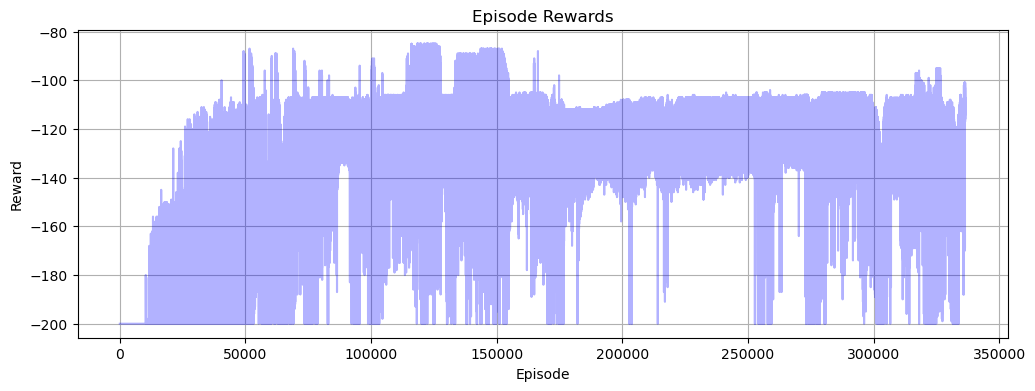

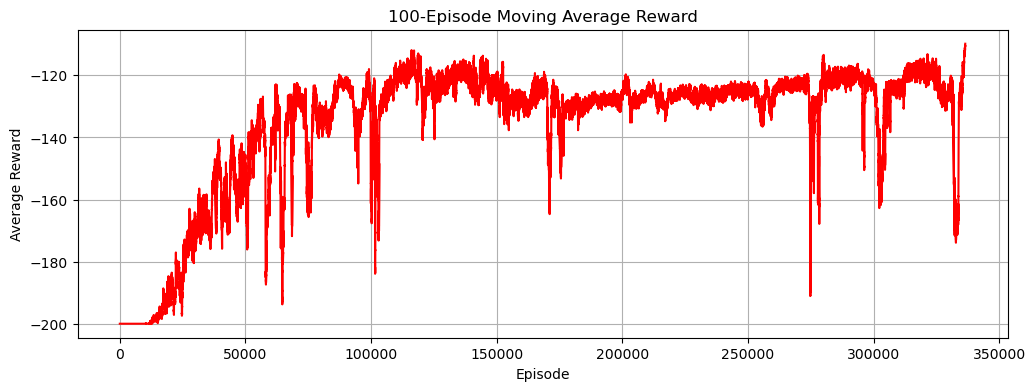

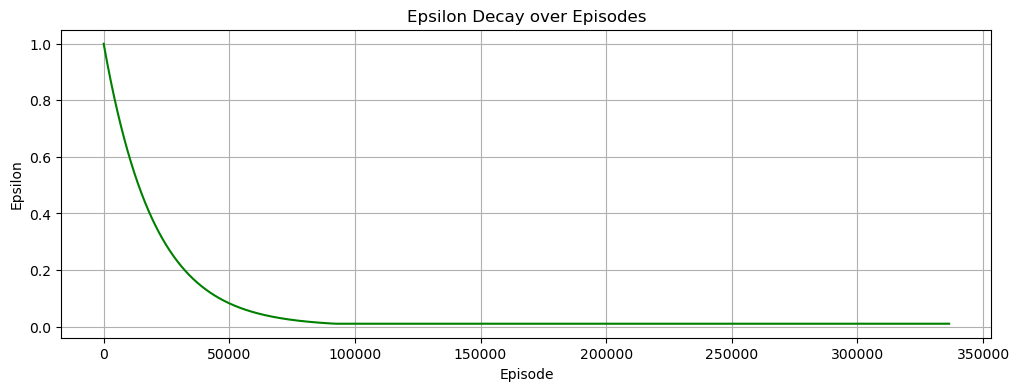

In [25]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)

plt.figure()
plt.plot(scores, color='blue', alpha=0.3)
plt.title('Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(avg_scores, color='red')
plt.title('100-Episode Moving Average Reward')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epsilons, color='green')
plt.title('Epsilon Decay over Episodes')
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.grid(True)
plt.show()


### **PART 3: AGENT EVALUATION**

In [26]:
eval_scores = visual_agent.evaluate(episodes=100)

print("Evaluation without exploration")
print("Mean evaluation score:", np.mean(eval_scores))
print("Best evaluation score:", np.max(eval_scores))
print("Worst evaluation score:", np.min(eval_scores))

Evaluation over 100 episodes:
Average Reward: -109.19
Max Reward: -102.0
Min Reward: -116.0
Evaluation without exploration
Mean evaluation score: -109.19
Best evaluation score: -102.0
Worst evaluation score: -116.0


In [27]:
watch_agent(visual_agent, episodes=5)

Episode 1 reward: -111.0
Episode 2 reward: -114.0
Episode 3 reward: -106.0
Episode 4 reward: -111.0
Episode 5 reward: -114.0


### **PART 4: EPSILON STRATEGY AND DISCRETIZATION GRANUALITY EXPERIMENTS**

In [28]:
def plot_training_result(scores, avg_scores, epsilons, title="Training Results"):
  
    fig, axs = plt.subplots(3, 1, figsize=(10, 15))
    fig.suptitle(title, fontsize=16)

    axs[0].plot(scores, alpha=0.6, color='blue')
    axs[0].set_title('Episode Rewards')
    axs[0].set_xlabel('Episode')
    axs[0].set_ylabel('Reward')

    axs[1].plot(avg_scores, color='red')
    axs[1].set_title('100-Episode Moving Average Reward')
    axs[1].set_xlabel('Episode')
    axs[1].set_ylabel('Average Reward')

    axs[2].plot(epsilons, color='green')
    axs[2].set_title('Epsilon over Episodes')
    axs[2].set_xlabel('Episode')
    axs[2].set_ylabel('Epsilon')

    plt.tight_layout()
    plt.show()



def run_epsilon_experiments(episodes=100000, buckets=(40, 40), seed=400):
   
    strategies = ['constant', 'linear', 'logarithmic', 'exponential']
    results = {}

    print("--- Running Epsilon Strategy Experiments ---")

    for strategy in strategies:
        print(f"\nTraining with '{strategy}' epsilon strategy...")
        env = gym.make('MountainCar-v0')
        agent = QLearningAgent(env, buckets=buckets, epsilon_strategy=strategy, episodes=episodes, seed=seed)
        
        sc, avg_sc, eps, _ = agent.train()
        
        eval_scores = agent.evaluate(episodes=100)
        
        results[strategy] = {
            'scores': sc,
            'avg_scores': avg_sc,
            'epsilons': eps,
            'eval_scores': eval_scores
        }
        
        plot_training_result(sc, avg_sc, eps, title=f"Training Results - {strategy.capitalize()} Strategy")
        env.close()

    plt.figure(figsize=(12, 6))
    for strategy in strategies:
        plt.plot(results[strategy]['avg_scores'], label=strategy)
    plt.title('Comparison of Moving Average Rewards across Epsilon Strategies')
    plt.xlabel('Episode')
    plt.ylabel('Average Reward (100 episodes)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(12, 6))
    for strategy in strategies:
        plt.plot(results[strategy]['epsilons'], label=strategy)
    plt.title('Comparison of Epsilon Schedules')
    plt.xlabel('Episode')
    plt.ylabel('Epsilon')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return results


def run_bucket_experiments(episodes=100000, seed=400):
   
    grids = [(5, 5), (100, 100)]
    results = {}

    print("\n--- Running Discretization Bucket Experiments ---")

    for grid in grids:
        print(f"\nTraining with {grid} buckets...")
        env = gym.make('MountainCar-v0')
        agent = QLearningAgent(env, buckets=grid, epsilon_strategy='exponential', episodes=episodes, seed=seed)
        
        _, avg_sc, _, _ = agent.train()
        
        results[grid] = {'avg_scores': avg_sc}
        env.close()

    plt.figure(figsize=(12, 6))
    for grid in grids:
        plt.plot(results[grid]['avg_scores'], label=f'{grid[0]}x{grid[1]} buckets')
    plt.title('Comparison of Moving Average Rewards for Different Discretization Grids')
    plt.xlabel('Episode')
    plt.ylabel('Average Reward (100 episodes)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return results


--- Running Epsilon Strategy Experiments ---

Training with 'constant' epsilon strategy...
threshold: -110.0
Episode 5000/100000 | Avg Score: -199.16 | Epsilon: 0.1000
Episode 10000/100000 | Avg Score: -182.10 | Epsilon: 0.1000
Episode 15000/100000 | Avg Score: -170.61 | Epsilon: 0.1000
Episode 20000/100000 | Avg Score: -163.93 | Epsilon: 0.1000
Episode 25000/100000 | Avg Score: -159.34 | Epsilon: 0.1000
Episode 30000/100000 | Avg Score: -155.70 | Epsilon: 0.1000
Episode 35000/100000 | Avg Score: -166.88 | Epsilon: 0.1000
Episode 40000/100000 | Avg Score: -142.58 | Epsilon: 0.1000
Episode 45000/100000 | Avg Score: -138.54 | Epsilon: 0.1000
Episode 50000/100000 | Avg Score: -165.29 | Epsilon: 0.1000
Episode 55000/100000 | Avg Score: -130.22 | Epsilon: 0.1000
Episode 60000/100000 | Avg Score: -141.92 | Epsilon: 0.1000
Episode 65000/100000 | Avg Score: -162.22 | Epsilon: 0.1000
Episode 70000/100000 | Avg Score: -150.95 | Epsilon: 0.1000
Episode 75000/100000 | Avg Score: -134.22 | Epsilon:

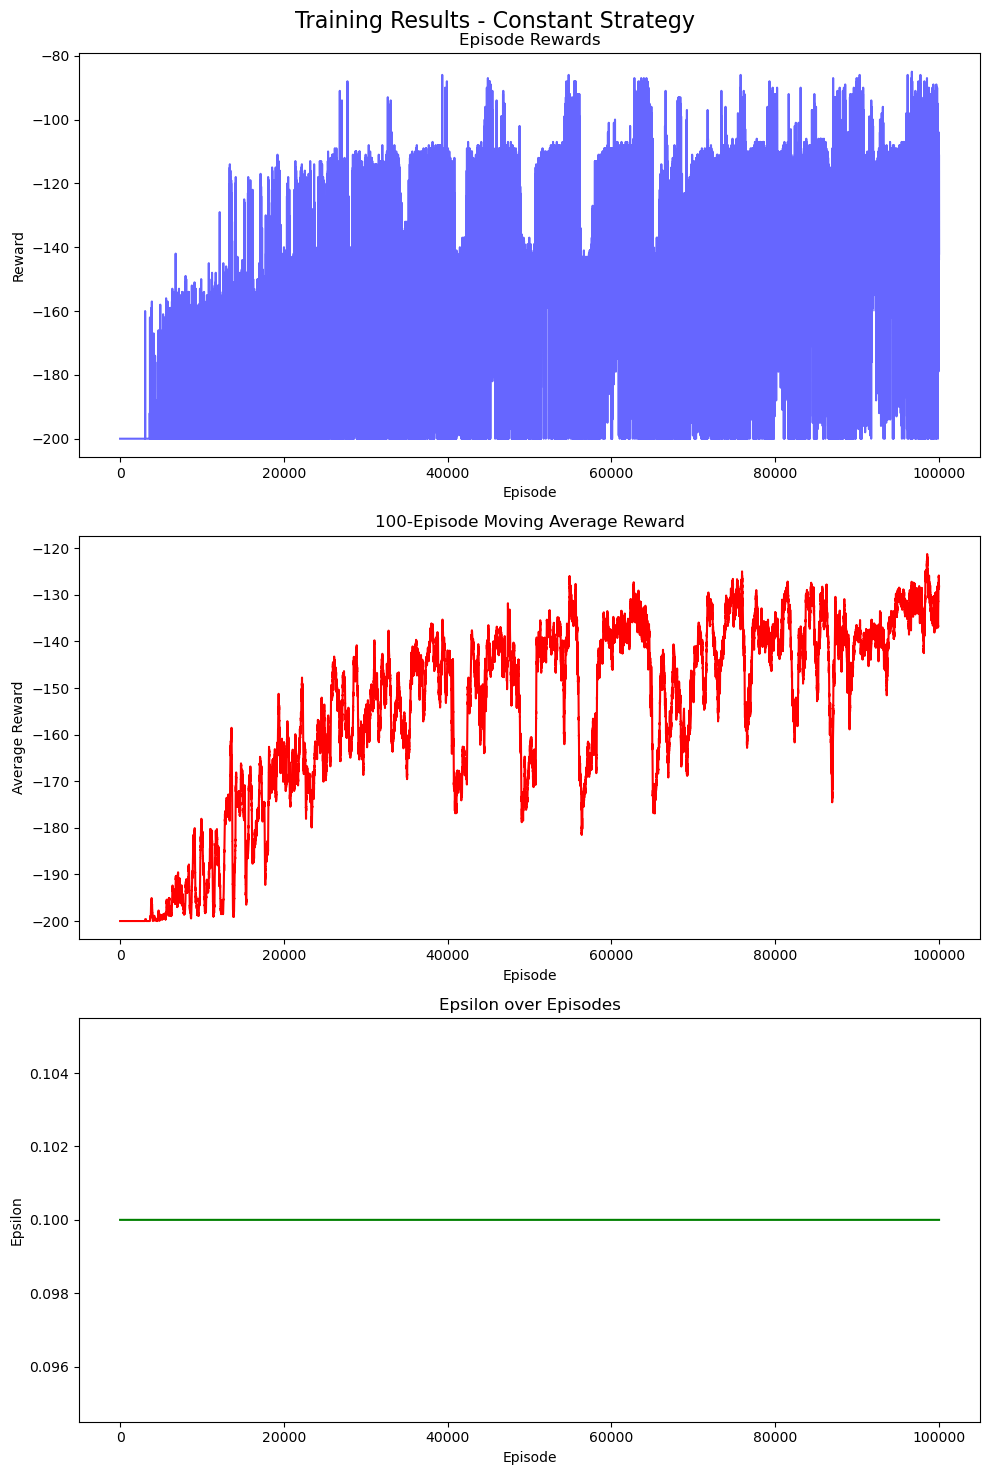


Training with 'linear' epsilon strategy...
threshold: -110.0
Episode 5000/100000 | Avg Score: -200.00 | Epsilon: 0.9381
Episode 10000/100000 | Avg Score: -200.00 | Epsilon: 0.8763
Episode 15000/100000 | Avg Score: -200.00 | Epsilon: 0.8144
Episode 20000/100000 | Avg Score: -200.00 | Epsilon: 0.7525
Episode 25000/100000 | Avg Score: -200.00 | Epsilon: 0.6906
Episode 30000/100000 | Avg Score: -199.70 | Epsilon: 0.6288
Episode 35000/100000 | Avg Score: -199.48 | Epsilon: 0.5669
Episode 40000/100000 | Avg Score: -196.54 | Epsilon: 0.5050
Episode 45000/100000 | Avg Score: -191.88 | Epsilon: 0.4431
Episode 50000/100000 | Avg Score: -185.44 | Epsilon: 0.3813
Episode 55000/100000 | Avg Score: -175.92 | Epsilon: 0.3194
Episode 60000/100000 | Avg Score: -161.87 | Epsilon: 0.2575
Episode 65000/100000 | Avg Score: -160.22 | Epsilon: 0.1956
Episode 70000/100000 | Avg Score: -145.19 | Epsilon: 0.1338
Episode 75000/100000 | Avg Score: -142.70 | Epsilon: 0.0719
Episode 80000/100000 | Avg Score: -130.

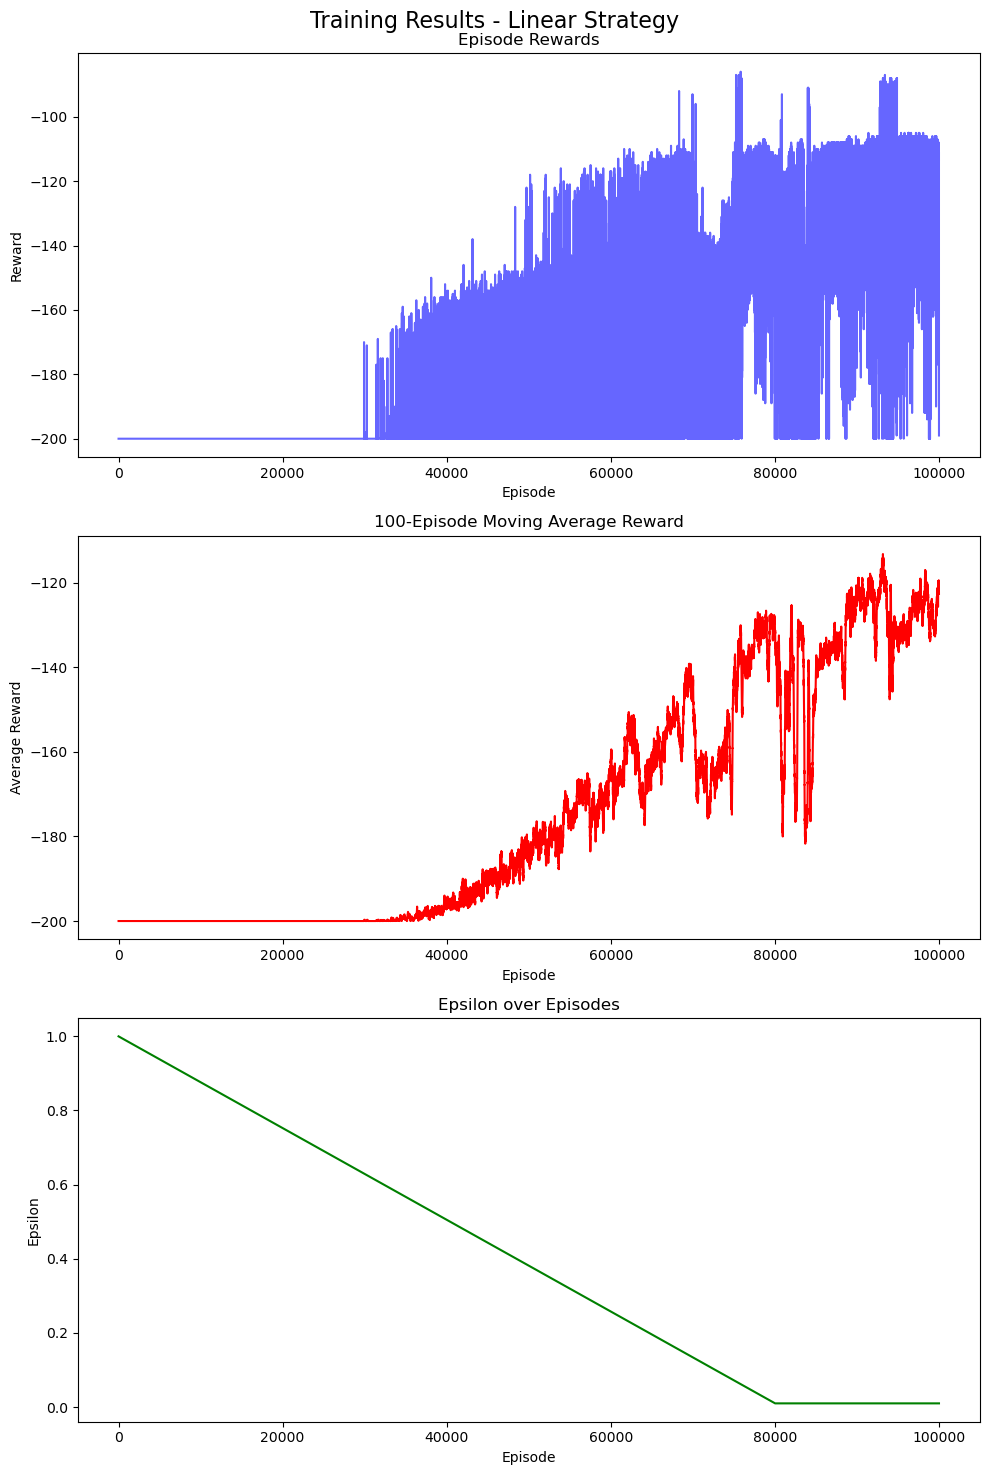


Training with 'logarithmic' epsilon strategy...
threshold: -110.0
Episode 5000/100000 | Avg Score: -199.92 | Epsilon: 0.2128
Episode 10000/100000 | Avg Score: -194.76 | Epsilon: 0.2000
Episode 15000/100000 | Avg Score: -182.40 | Epsilon: 0.1932
Episode 20000/100000 | Avg Score: -176.10 | Epsilon: 0.1886
Episode 25000/100000 | Avg Score: -170.93 | Epsilon: 0.1853
Episode 30000/100000 | Avg Score: -158.21 | Epsilon: 0.1826
Episode 35000/100000 | Avg Score: -150.10 | Epsilon: 0.1804
Episode 40000/100000 | Avg Score: -149.43 | Epsilon: 0.1785
Episode 45000/100000 | Avg Score: -156.75 | Epsilon: 0.1769
Episode 50000/100000 | Avg Score: -174.16 | Epsilon: 0.1755
Episode 55000/100000 | Avg Score: -143.51 | Epsilon: 0.1742
Episode 60000/100000 | Avg Score: -157.67 | Epsilon: 0.1731
Episode 65000/100000 | Avg Score: -143.38 | Epsilon: 0.1720
Episode 70000/100000 | Avg Score: -146.62 | Epsilon: 0.1711
Episode 75000/100000 | Avg Score: -143.86 | Epsilon: 0.1702
Episode 80000/100000 | Avg Score: 

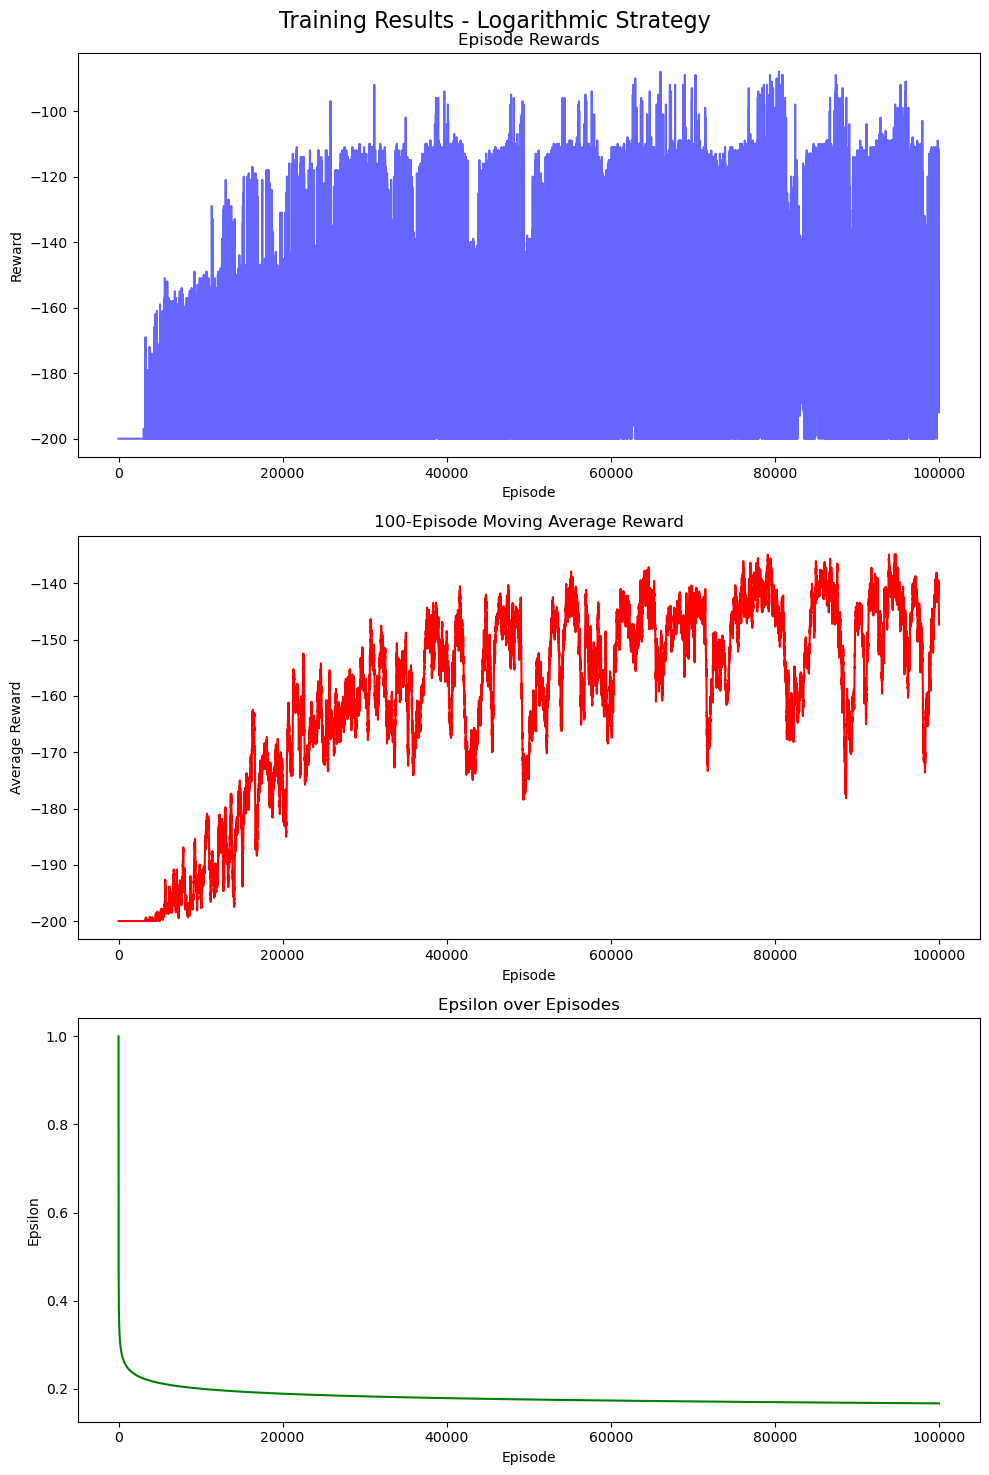


Training with 'exponential' epsilon strategy...
threshold: -110.0
Episode 5000/100000 | Avg Score: -200.00 | Epsilon: 0.7788
Episode 10000/100000 | Avg Score: -200.00 | Epsilon: 0.6066
Episode 15000/100000 | Avg Score: -198.50 | Epsilon: 0.4724
Episode 20000/100000 | Avg Score: -188.96 | Epsilon: 0.3679
Episode 25000/100000 | Avg Score: -188.79 | Epsilon: 0.2865
Episode 30000/100000 | Avg Score: -174.83 | Epsilon: 0.2231
Episode 35000/100000 | Avg Score: -163.94 | Epsilon: 0.1738
Episode 40000/100000 | Avg Score: -153.37 | Epsilon: 0.1353
Episode 45000/100000 | Avg Score: -143.68 | Epsilon: 0.1054
Episode 50000/100000 | Avg Score: -155.13 | Epsilon: 0.0821
Episode 55000/100000 | Avg Score: -131.36 | Epsilon: 0.0639
Episode 60000/100000 | Avg Score: -143.46 | Epsilon: 0.0498
Episode 65000/100000 | Avg Score: -174.55 | Epsilon: 0.0388
Episode 70000/100000 | Avg Score: -124.86 | Epsilon: 0.0302
Episode 75000/100000 | Avg Score: -147.07 | Epsilon: 0.0235
Episode 80000/100000 | Avg Score: 

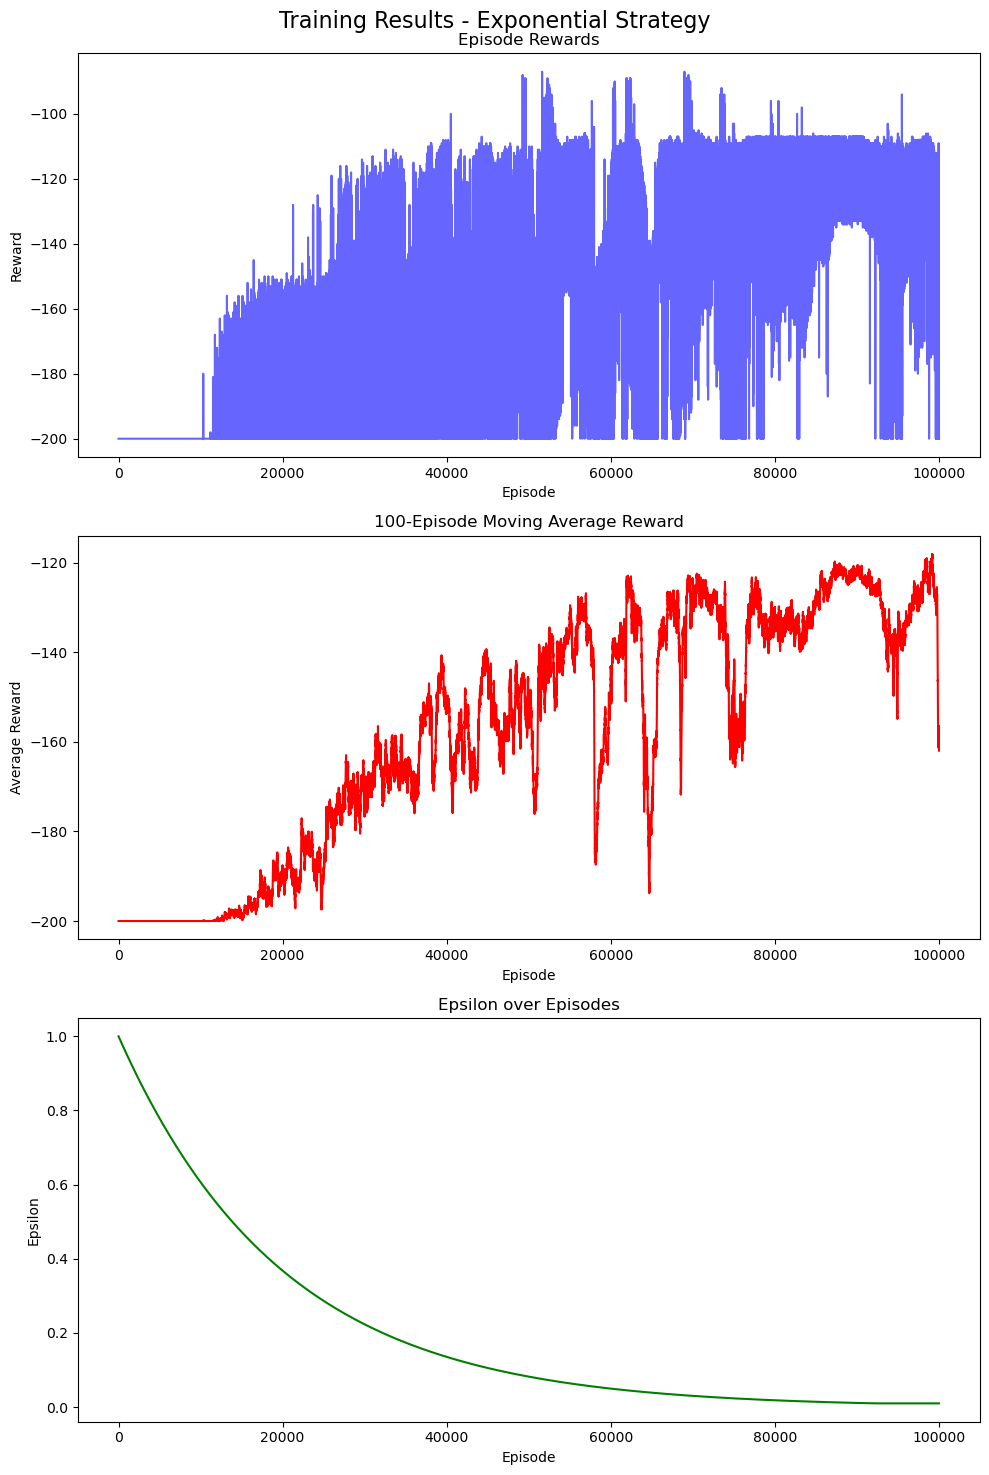

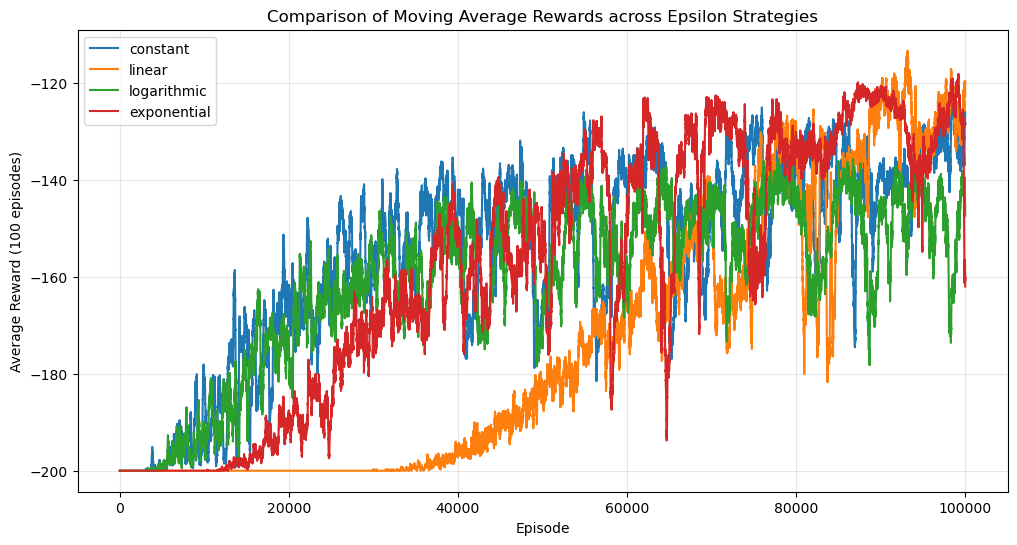

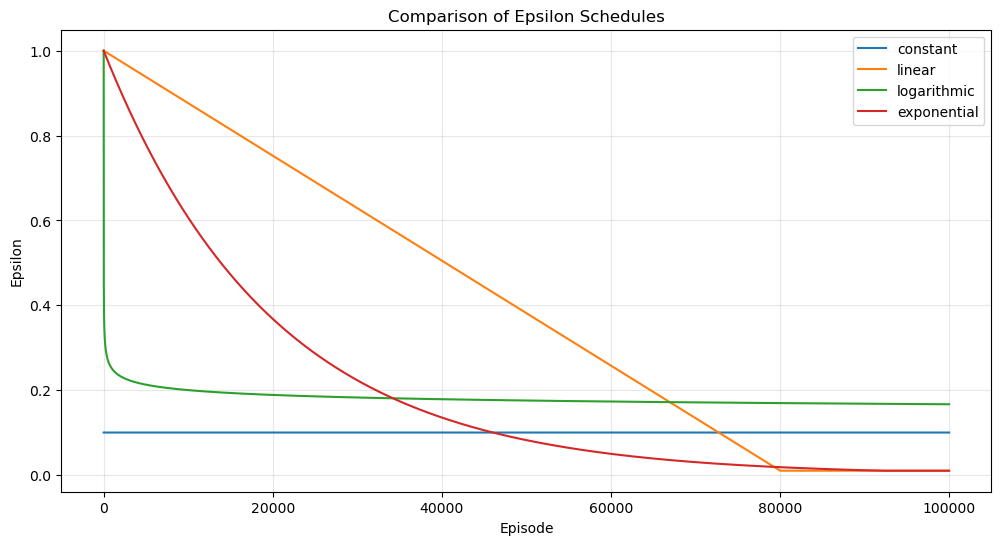

In [29]:
epsilon_results = run_epsilon_experiments(
    episodes=100000,
    buckets=(40, 40),
    seed=400
)


--- Running Discretization Bucket Experiments ---

Training with (5, 5) buckets...
threshold: -110.0
Episode 5000/100000 | Avg Score: -200.00 | Epsilon: 0.7788
Episode 10000/100000 | Avg Score: -200.00 | Epsilon: 0.6066
Episode 15000/100000 | Avg Score: -200.00 | Epsilon: 0.4724
Episode 20000/100000 | Avg Score: -200.00 | Epsilon: 0.3679
Episode 25000/100000 | Avg Score: -200.00 | Epsilon: 0.2865
Episode 30000/100000 | Avg Score: -200.00 | Epsilon: 0.2231
Episode 35000/100000 | Avg Score: -200.00 | Epsilon: 0.1738
Episode 40000/100000 | Avg Score: -200.00 | Epsilon: 0.1353
Episode 45000/100000 | Avg Score: -200.00 | Epsilon: 0.1054
Episode 50000/100000 | Avg Score: -200.00 | Epsilon: 0.0821
Episode 55000/100000 | Avg Score: -200.00 | Epsilon: 0.0639
Episode 60000/100000 | Avg Score: -200.00 | Epsilon: 0.0498
Episode 65000/100000 | Avg Score: -200.00 | Epsilon: 0.0388
Episode 70000/100000 | Avg Score: -200.00 | Epsilon: 0.0302
Episode 75000/100000 | Avg Score: -196.86 | Epsilon: 0.0235

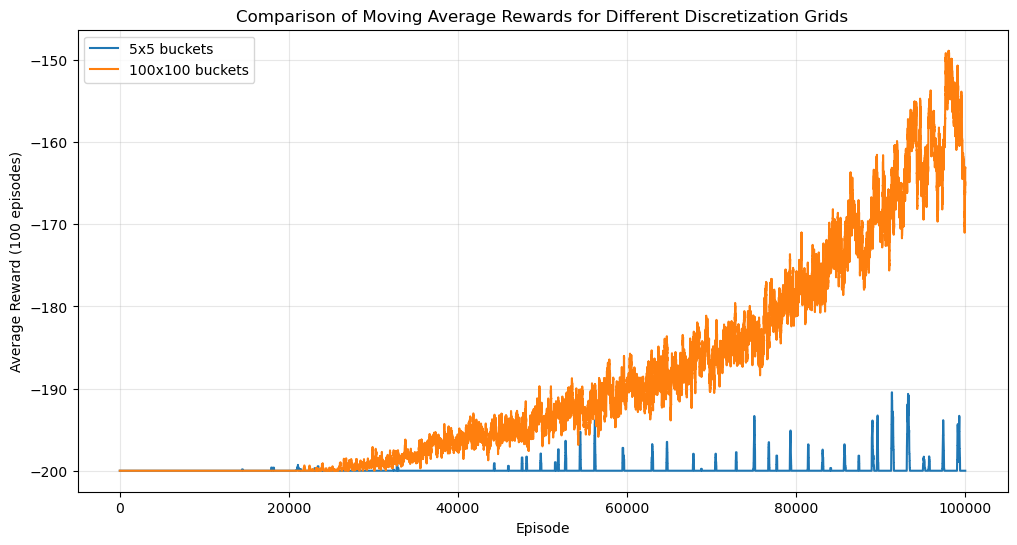

In [33]:
bucket_results = run_bucket_experiments(
    episodes=100000,
    seed=400
)